In [23]:
library(tidyverse)
library(glue)
library(patchwork)

In [24]:
sessionInfo()

R version 4.2.1 (2022-06-23)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS Big Sur ... 10.16

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/lib/libopenblasp-r0.3.20.dylib

locale:
[1] C/C.UTF-8/C/C/C/C

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] patchwork_1.3.0 glue_1.7.0      lubridate_1.9.3 forcats_1.0.0  
 [5] stringr_1.5.1   dplyr_1.1.4     purrr_1.0.2     readr_2.1.5    
 [9] tidyr_1.3.1     tibble_3.2.1    ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] pillar_1.10.2      compiler_4.2.1     RColorBrewer_1.1-3 base64enc_0.1-3   
 [5] tools_4.2.1        bit_4.0.5          digest_0.6.36      uuid_1.2-0        
 [9] viridisLite_0.4.2  timechange_0.3.0   jsonlite_1.8.8     evaluate_1.0.3    
[13] lifecycle_1.0.4    gtable_0.3.6       pkgconfig_2.0.3    rlang_1.1.4       
[17] IRdisplay_1.1      cli_3.6.3          crosstalk_1.

In [25]:
# Run mmseqs for every reference against the complete references
system("mkdir -p data-preparation/mmseqs-results")
system("mkdir -p data-preparation/tmp")
# Uncomment to run mmseqs2 searches
consensus_files <- list.files("data-preparation/consensus", pattern = "\\.fasta$", full.names = TRUE)

colnames_mmseqs <- c("query,target,fident,alnlen,mismatch,gapopen,qstart,qend,qlen,tstart,tend,tlen,evalue,bits")

# walk(consensus_files, function(fasta) {
#   basename <- str_remove(basename(fasta), "\\.fasta$")
#   potential_references <- "data-preparation/ncbi-virus-fasta/sequences_20251024_LASV.fasta"
#   message(glue("Running mmseqs2 for {basename}\n"))
#   system(glue("conda run -n mmseqs2-env mmseqs easy-search --max-seq-id 1.0 --search-type 3 --format-output {colnames_mmseqs} {fasta} {potential_references} data-preparation/mmseqs-results/{basename}_mmseqs.out.m8 data-preparation/tmp"))
# })

In [26]:
# Combine mmseqs results
mmseqs <- list.files("data-preparation/mmseqs-results/") %>%
    map_dfr(~ {
        df <- read.table(paste0("data-preparation/mmseqs-results/", .), sep="\t", col.names = str_split(colnames_mmseqs, ",")[[1]])
        df$segment <- .
        df
    }) %>%
    mutate(segment = gsub(".*_(S|L|M)_.*", "\\1", segment))%>%
    mutate(query = gsub("_[L|S]","", query ))%>%
    filter(fident >=0.64) %>%
    filter((tlen >=6700 & tlen <=7500) | (tlen >=2900 & tlen <=3600))%>%
    mutate(fident_window = cut(as.numeric(fident), breaks = seq(0.64, 1, by = 0.02), include.lowest = TRUE))

set.seed(42)
selected_references <- mmseqs %>%
    group_by(query, segment, fident_window) %>%
    slice_max(order_by = bits, n=1, with_ties = FALSE) %>%
    ungroup()%>%
    arrange(query, segment, desc(fident))

mmseqs <- merge(mmseqs, selected_references%>%mutate(is_selected = TRUE)%>%select(query,target,bits, is_selected), by = c("query","target","bits"), all.x=TRUE)%>%
  mutate(is_selected = ifelse(is.na(is_selected), FALSE, is_selected))

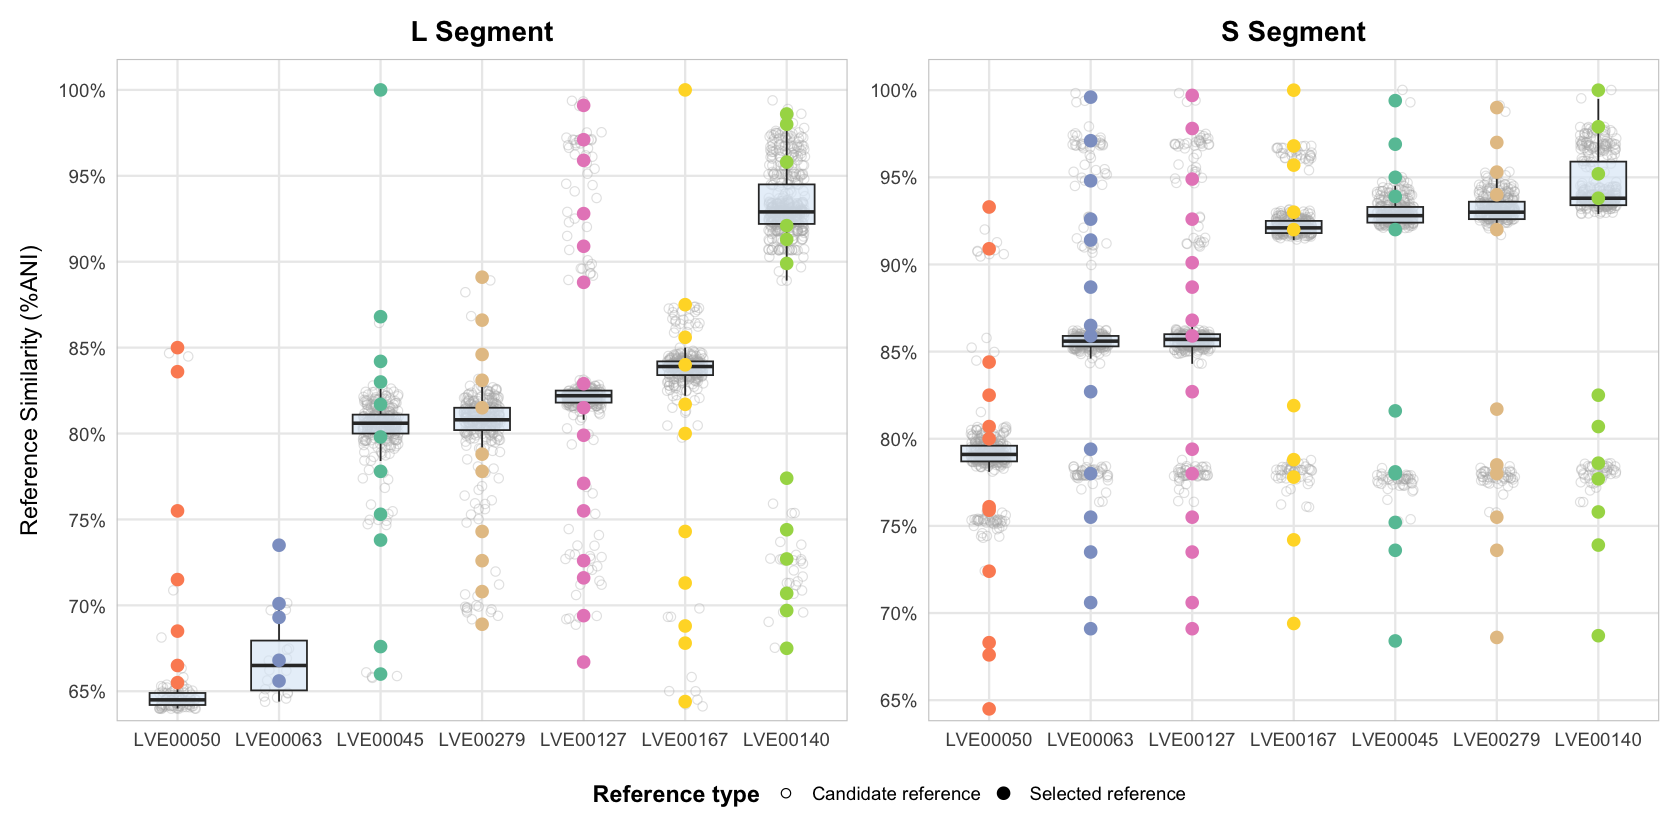

In [30]:
options(repr.plot.width = 14, repr.plot.height = 7)

mmseqs_plot <- mmseqs %>%
    filter(query != "LVE00223") %>%
    mutate(
        selection = if_else(is_selected, "Selected reference", "Candidate reference"),
        selection = factor(selection, levels = c("Selected reference", "Candidate reference")),
        segment = recode(segment, "L" = "L segment", "S" = "S segment", "M" = "M segment")
    ) %>%
    tidyr::drop_na(fident)

# Define common theme
theme_style <- theme_minimal(base_size = 14) +
    theme(
        # axis.text.x = element_blank(),
        axis.title.x = element_text(margin = margin(t = 10)),
        axis.title.y = element_text(margin = margin(r = 10)),
        panel.grid.minor = element_blank(),
        panel.border = element_rect(colour = "grey80", fill = NA),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        legend.position = "bottom",
        legend.box = "horizontal",
        legend.title = element_text(face = "bold")
    )

# Plot L Segment
p_L <- ggplot(filter(mmseqs_plot, segment == "L segment"),
              aes(x = reorder(query, fident, median, na.rm = TRUE), y = fident)) +
    geom_jitter(
        data = filter(mmseqs_plot, segment == "L segment", !is_selected),
        aes(color = "grey", shape = selection, alpha = selection),
        width = 0.18, size = 2.3
    ) +
    geom_boxplot(
        aes(group = query),
        width = 0.55, fill = "#deebf7", alpha = 0.7, outlier.shape = NA
    ) +
    geom_point(
        data = filter(mmseqs_plot, segment == "L segment", is_selected),
        aes(color = query, shape = selection, alpha = selection),
        size = 3.5
    ) +
    scale_color_brewer(palette = "Set2") +
    scale_shape_manual(
        values = c("Selected reference" = 16, "Candidate reference" = 1),
        guide = guide_legend(title = "Reference type")
    ) +
    scale_alpha_manual(values = c("Selected reference" = 1, "Candidate reference" = 0.35), guide = "none") +
    scale_y_continuous(
        labels = scales::percent_format(accuracy = 1),
        breaks = scales::pretty_breaks(n = 6),
        expand = expansion(mult = c(0.02, 0.05))
    ) +
    labs(x = NULL, y = "Reference Similarity (%ANI)", title = "L Segment") +
    theme_style +
    guides(color = "none")

# Plot S Segment
p_S <- ggplot(filter(mmseqs_plot, segment == "S segment"),
              aes(x = reorder(query, fident, median, na.rm = TRUE), y = fident)) +
    geom_jitter(
        data = filter(mmseqs_plot, segment == "S segment", !is_selected),
        aes(color = "grey", shape = selection, alpha = selection),
        width = 0.18, size = 2.3
    ) +
    geom_boxplot(
        aes(group = query),
        width = 0.55, fill = "#deebf7", alpha = 0.7, outlier.shape = NA
    ) +
    geom_point(
        data = filter(mmseqs_plot, segment == "S segment", is_selected),
        aes(color = query, shape = selection, alpha = selection),
        size = 3.5
    ) +
    scale_color_brewer(palette = "Set2") +
    scale_shape_manual(
        values = c("Selected reference" = 16, "Candidate reference" = 1),
        guide = guide_legend(title = "Reference type")
    ) +
    scale_alpha_manual(values = c("Selected reference" = 1, "Candidate reference" = 0.35), guide = "none") +
    scale_y_continuous(
        labels = scales::percent_format(accuracy = 1),
        breaks = scales::pretty_breaks(n = 6),
        expand = expansion(mult = c(0.02, 0.05))
    ) +
    labs(x = NULL, y = NULL, title = "S Segment") +
    theme_style +
    guides(color = "none")

# Combine
p <- (p_L | p_S) +
        plot_layout(guides = "collect") +
        plot_annotation(
            theme = theme(
                plot.title = element_text(hjust = 0.5, face = "bold"),
                plot.subtitle = element_text(hjust = 0.5)
            )
        ) & theme(legend.position = "bottom")

p

# Save plot
ggsave("images/supplfig-2_reference_selection.png", p, width = 14, height = 7, dpi = 300)
ggsave("../../../Fig/supplfig2.png", p, width = 14, height = 7, dpi = 300)

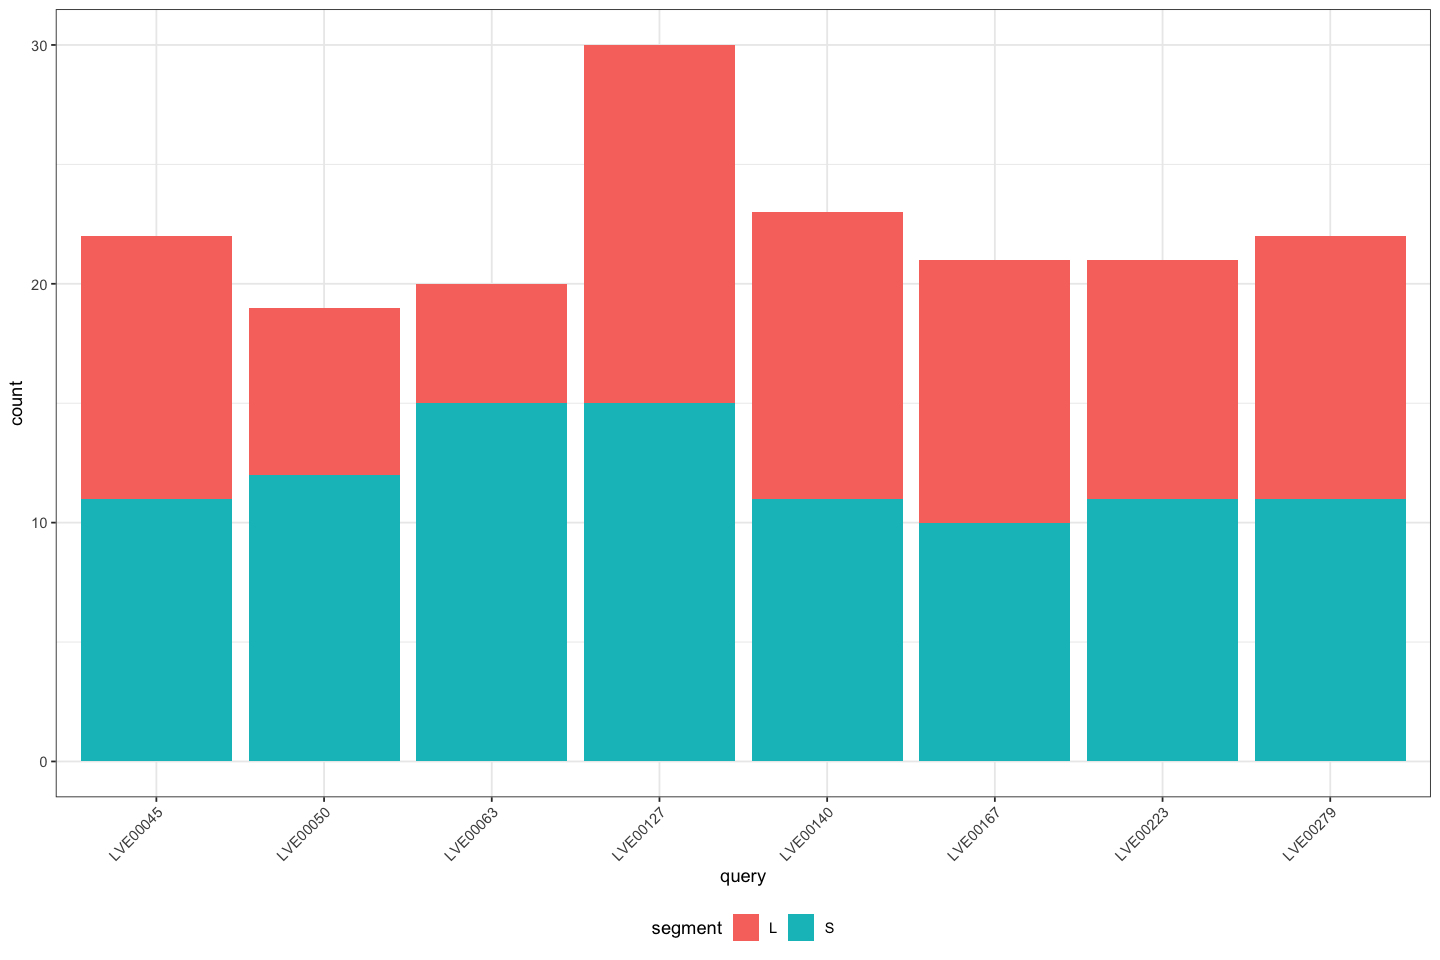

In [5]:
# Checking how many we have for every query
ggplot(selected_references, aes(x = query, fill = segment)) +
  geom_bar() +
  theme_bw() +
  theme(legend.position = "bottom") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

The coverage on L for LVE00063 is just very bad.
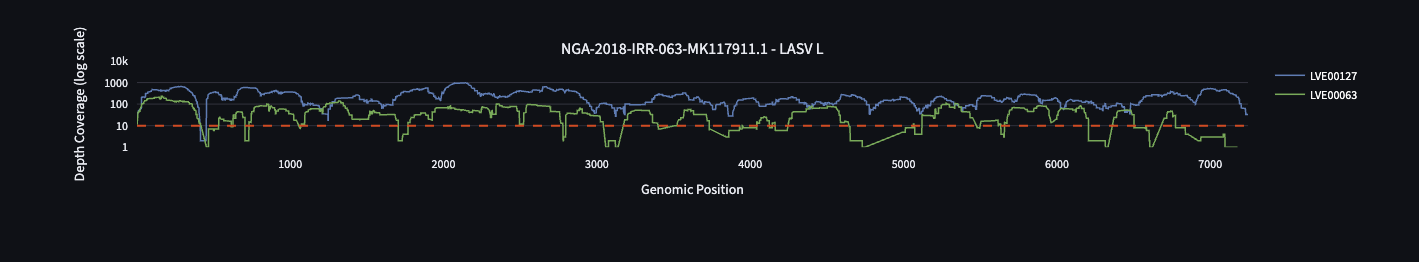


Not going to worry too much about it, I'm just going to start by selecting one sample (LVE00050) and one reference per window of identity.


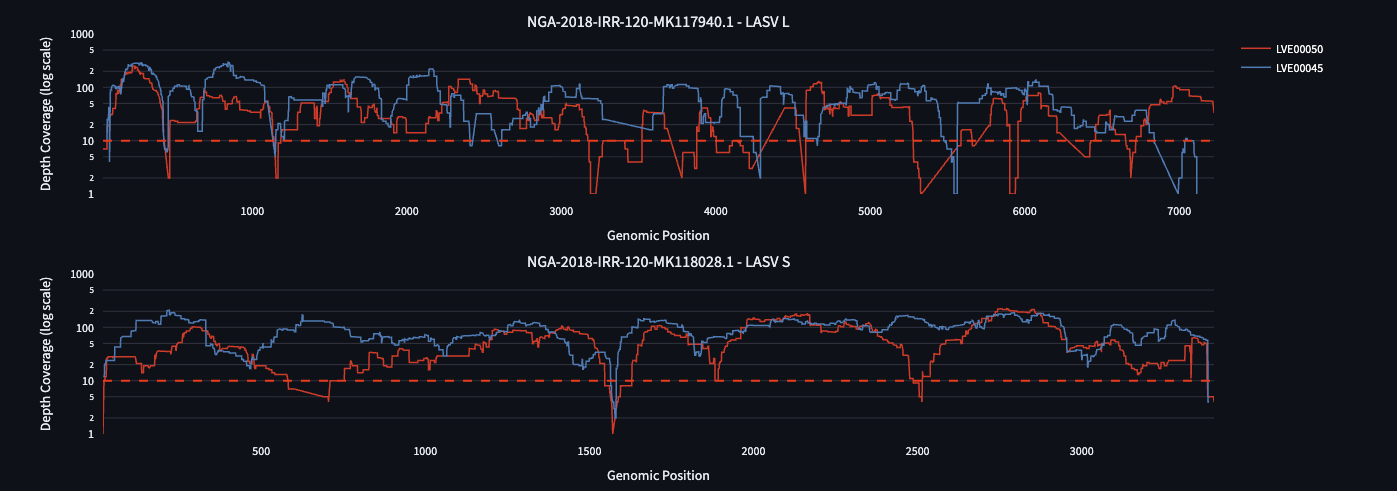


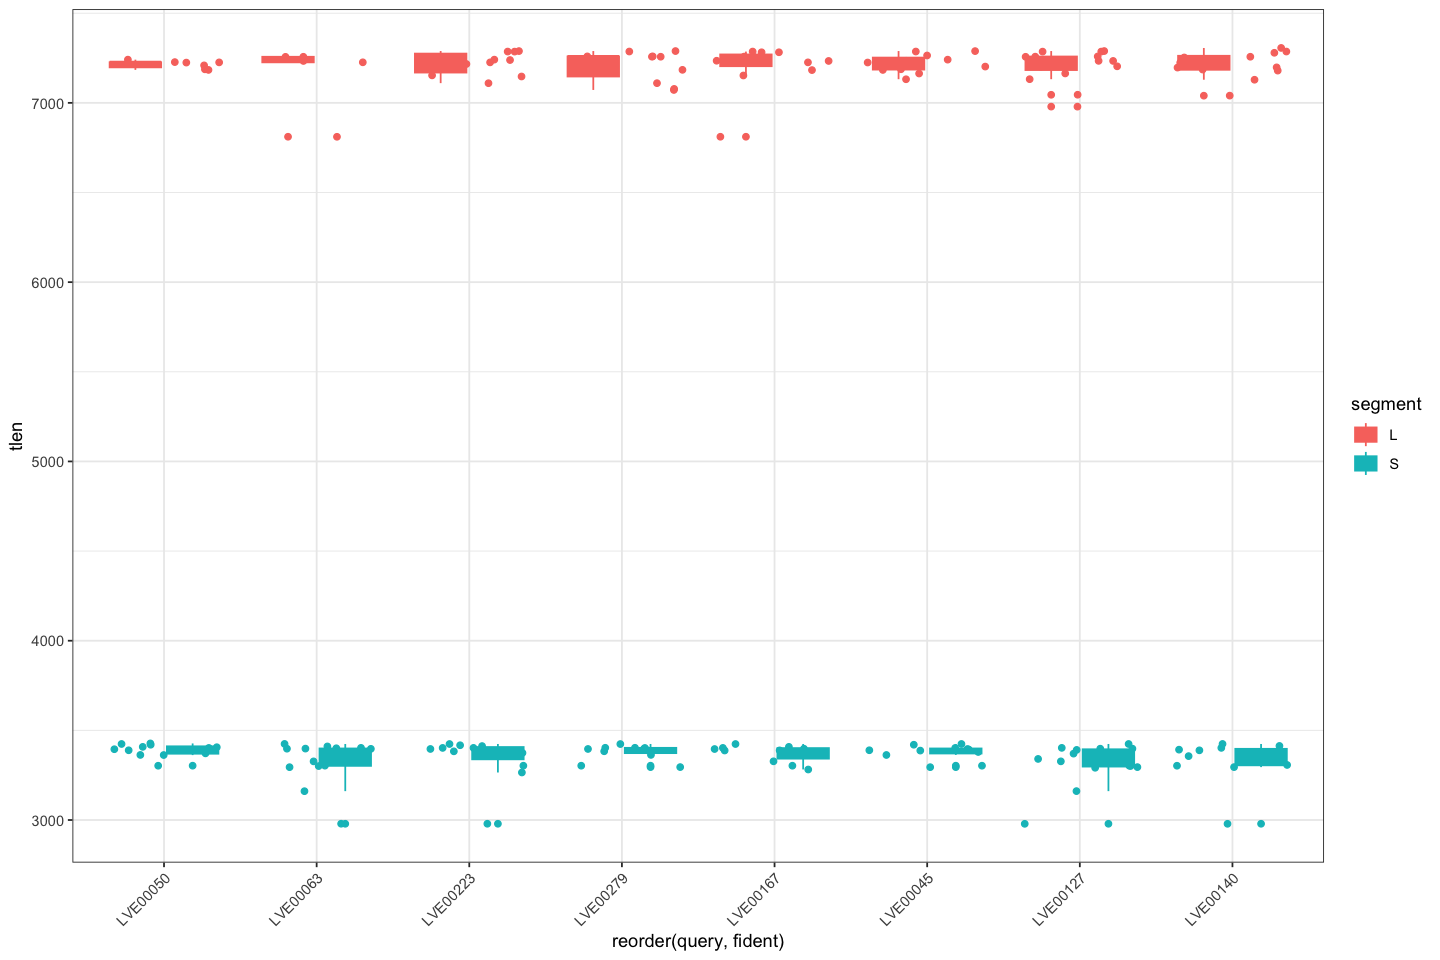

In [6]:
# Checking the observed diversity of references. (arrange with increasing mean fident)
ggplot(selected_references, aes(y = tlen, x = reorder(query, fident), fill = segment, color=segment)) +
  geom_boxplot() +
  geom_jitter() +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [7]:
fident_window_to_digits <- function(x) {
  rng <- str_match(as.character(x), "\\[?(0?\\.\\d+),\\s*(1|0?\\.\\d+)\\]")
  lo <- as.numeric(rng[, 2])
  hi <- as.numeric(rng[, 3])
  sprintf("%02d%02d", round(lo * 100), round(hi * 100))
}

system("mkdir -p data-preparation/selected-references")

write_tsv(selected_references, "data-preparation/selected-references/selected_references.tsv")

out_dir <- "data-preparation/selected-references"

collapse <- selected_references%>%
    group_by(query, fident_window)%>%
    summarise(
      targets_regex = paste(target,collapse = " " ),
      segment = paste(segment, collapse =" ")
    )%>%
    ungroup()

`summarise()` has grouped output by 'query'. You can override using the
`.groups` argument.


In [109]:
head(collapse)

query,fident_window,targets_regex,segment
<chr>,<fct>,<chr>,<chr>
LVE00045,"[0.64,0.66]",MT199231.1,L
LVE00045,"(0.66,0.68]",MT199235.1,L
LVE00045,"(0.68,0.7]",OR041677.1,S
LVE00045,"(0.72,0.74]",PQ541162.1 OR041684.1,L S
LVE00045,"(0.74,0.76]",MK117836.1 OQ919510.1,L S
LVE00045,"(0.76,0.78]",MH053566.1 AY628205.1,L S


In [ ]:
system("mkdir -p data-preparation/selected-references")

apply(collapse, 1, function(x) {
    sample <- x[1]
    fident_window <- x[2]
    targets_regex <- x[3]
    fident_digits <- fident_window_to_digits(fident_window)
    outname <- gsub(" ", "-", targets_regex)
    regex <- gsub(" ",")|(", targets_regex)
    out_file <- glue("{out_dir}/{fident_digits}_{outname}.fasta")
    command <- glue("cat data-preparation/ncbi-virus-fasta/sequences_*_LASV.fasta | seqkit grep -r -p '({regex})' > {out_file}")
    system(command)
})

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [38] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [75] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[112] 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [111]:
unique(collapse$query)

[1] "LVE00045" "LVE00050" "LVE00063" "LVE00127" "LVE00140" "LVE00167" "LVE00223"
[8] "LVE00279"

In [112]:
RVDB <- data.frame(
        sample = unique(collapse$query),
        sequence = rep("/lustre1/project/stg_00132/databases/RVDB/U-RVDBv29.0.fasta", length(unique(collapse$query))))%>%
    mutate(
        id= glue("{sample}-RVDB")
    )

collapse%>%
    mutate(
        id= glue("{query}-{fident_window_to_digits(fident_window)}"),
        sample = query,
        sequence = glue("{out_dir}/{fident_window_to_digits(fident_window)}_{gsub(' ', '-', targets_regex)}.fasta")
    )%>%
    select(id, sample, sequence, segment)%>%
    bind_rows(., RVDB)%>%
    arrange(sample)%>%
    write_csv( "reference_pools.csv")